# Student Performance Analysis & Pass Prediction

---



# Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load Dataset

In [2]:
# Load Math dataset
df = pd.read_csv("mat2.csv")

df.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,GP,F,18,U,GT3,A,4,4,at_home,...,4,3,4,1,1,3,6,5,6,6
1,1,GP,F,17,U,GT3,T,1,1,at_home,...,5,3,3,1,1,3,4,5,5,6
2,2,GP,F,15,U,LE3,T,1,1,at_home,...,4,3,2,2,3,3,10,7,8,10
3,3,GP,F,15,U,GT3,T,4,2,health,...,3,2,2,1,1,5,2,15,14,15
4,4,GP,F,16,U,GT3,T,3,3,other,...,4,3,2,1,2,5,4,6,10,10


# Dataset Overview

In [3]:
# Shape of data
print("Rows, Columns:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

Rows, Columns: (395, 34)

Columns:
 Index(['Unnamed: 0', 'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
       'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

Data Types:

Unnamed: 0     int64
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout

In [4]:
df.describe()

,Unnamed: 0,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,197.000000,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,114.170924,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,0.000000,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,98.500000,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,197.000000,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,295.500000,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,394.000000,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Final Marks Distribution

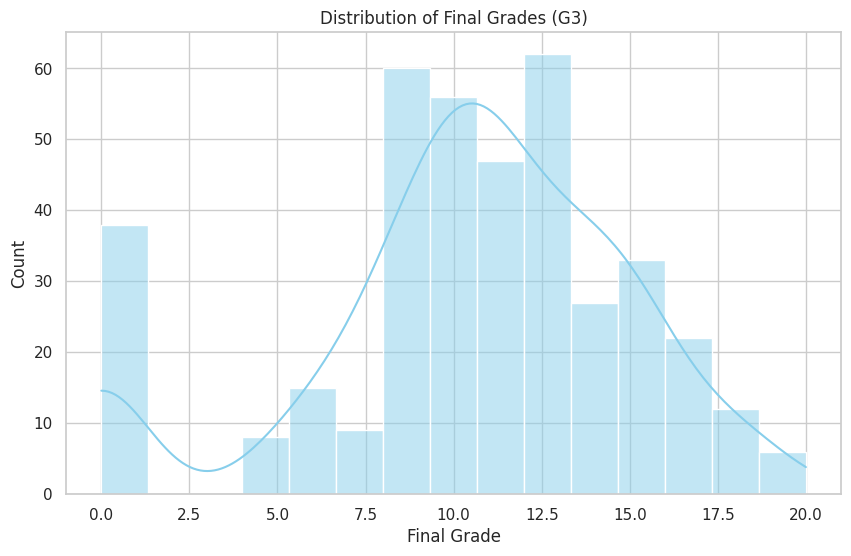

In [5]:
sns.histplot(df["G3"], bins=15, kde=True, color="skyblue")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()

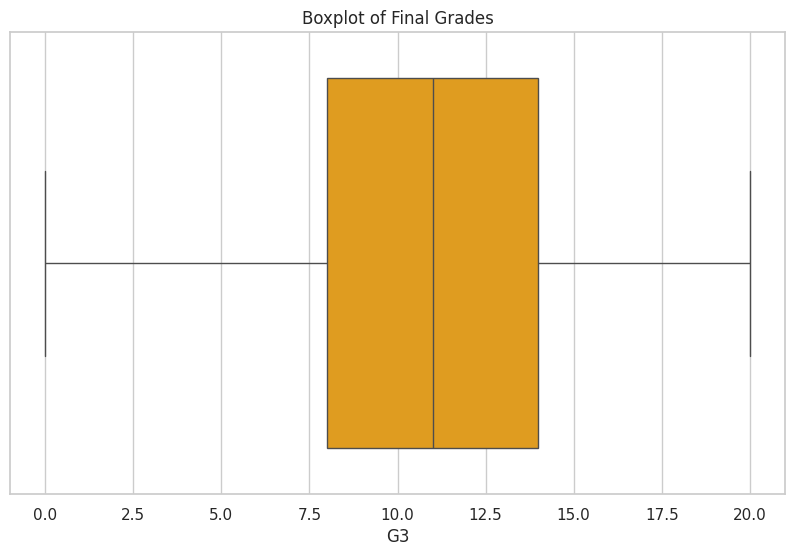

In [6]:
# Boxplot of Final Marks
sns.boxplot(x=df["G3"], color="orange")
plt.title("Boxplot of Final Grades")
plt.show()

# Marks vs Study Hours

/tmp/ipykernel_1927/2620533916.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="studytime", y="G3", data=df, palette="viridis")


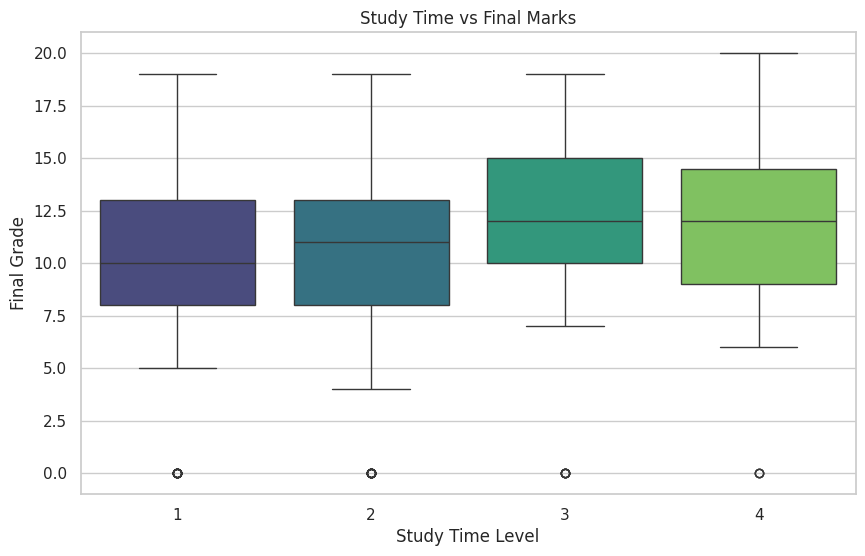

In [7]:
sns.boxplot(x="studytime", y="G3", data=df, palette="viridis")
plt.title("Study Time vs Final Marks")
plt.xlabel("Study Time Level")
plt.ylabel("Final Grade")
plt.show()

# Gender Analysis

/tmp/ipykernel_1927/1302035957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg.index, y=gender_avg.values, palette="Set2")


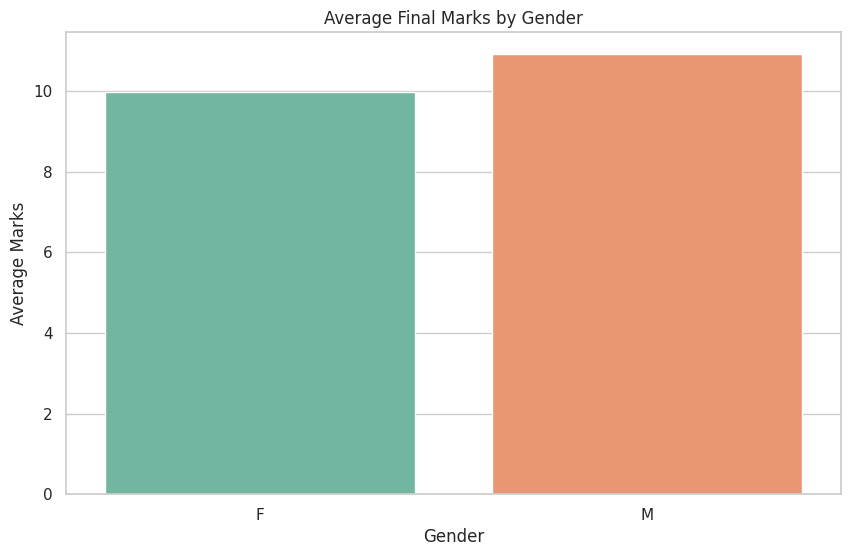

In [8]:
gender_avg = df.groupby("sex")["G3"].mean()

sns.barplot(x=gender_avg.index, y=gender_avg.values, palette="Set2")
plt.title("Average Final Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Marks")
plt.show()

# Pass / Fail

In [9]:
# Pass = 1 if marks >=10 else Fail = 0
df["Pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

df[["G3", "Pass"]].head()

,G3,Pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


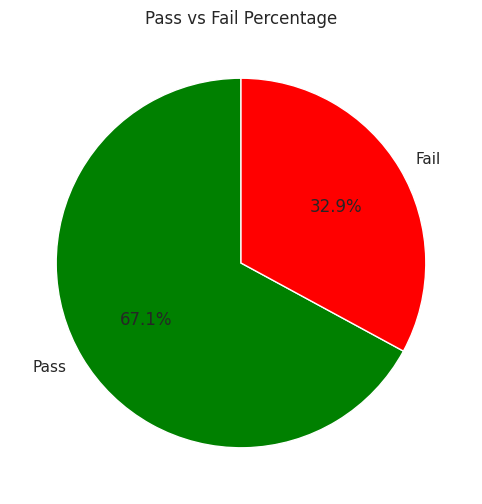

In [10]:
# Pass Percentage
pass_counts = df["Pass"].value_counts()

plt.pie(pass_counts, labels=["Pass", "Fail"], autopct="%1.1f%%", startangle=90, colors=["green", "red"])
plt.title("Pass vs Fail Percentage")
plt.show()

# Failures vs Final Marks

/tmp/ipykernel_1927/2523332996.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failures", y="G3", data=df, palette="coolwarm")


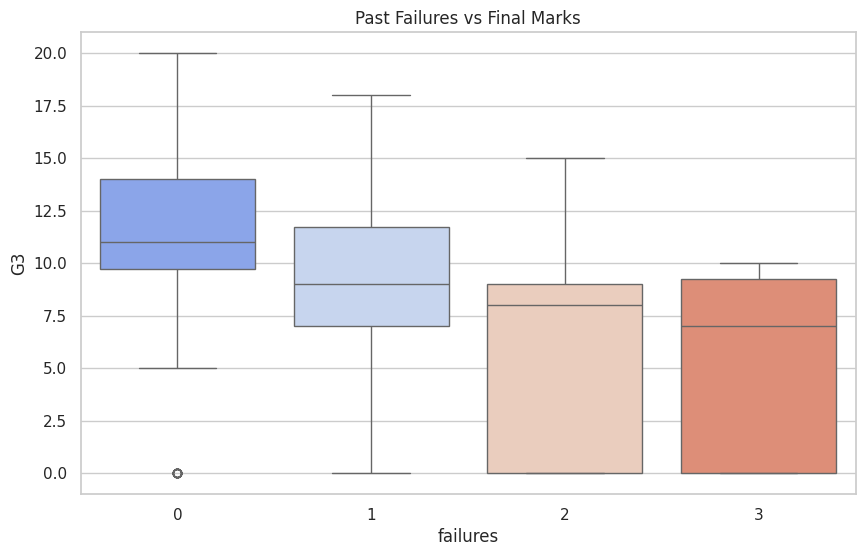

In [11]:
sns.boxplot(x="failures", y="G3", data=df, palette="coolwarm")
plt.title("Past Failures vs Final Marks")
plt.show()

# Family Support Analysis

/tmp/ipykernel_1927/430679972.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="famsup", y="G3", data=df, palette="pastel")


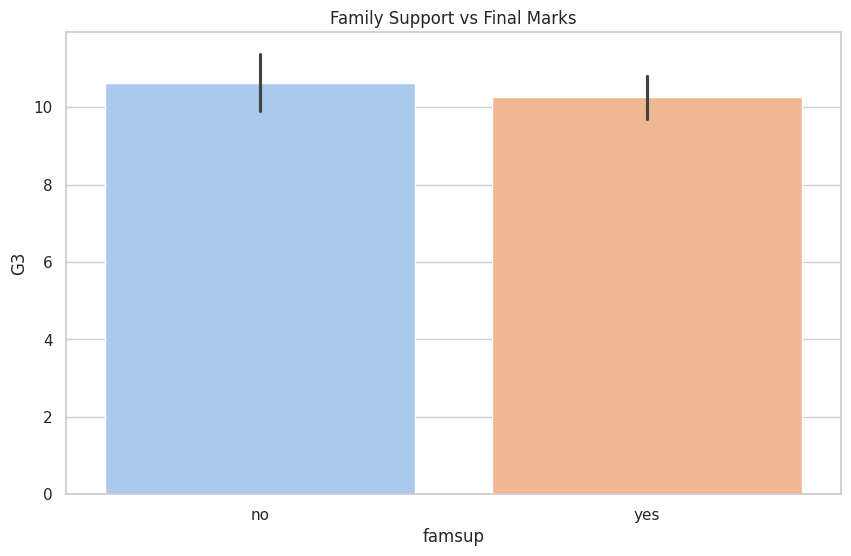

In [12]:
sns.barplot(x="famsup", y="G3", data=df, palette="pastel")
plt.title("Family Support vs Final Marks")
plt.show()

# Encode Categorical Data

In [15]:
df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,0,18,1,0,0,4,4,0,...,3,4,1,1,3,6,5,6,6,0
1,1,0,0,17,1,0,1,1,1,0,...,3,3,1,1,3,4,5,5,6,0
2,2,0,0,15,1,1,1,1,1,0,...,3,2,2,3,3,10,7,8,10,1
3,3,0,0,15,1,0,1,4,2,1,...,2,2,1,1,5,2,15,14,15,1
4,4,0,0,16,1,0,1,3,3,2,...,3,2,1,2,5,4,6,10,10,1


Machine learning needs numbers, so convert text columns.

# Feature Selection

In [16]:
X = df_ml.drop(["G3", "Pass"], axis=1)
y = df_ml["Pass"]

print("Features Shape:", X.shape)

Features Shape: (395, 33)


# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (316, 33)
Test Size: (79, 33)


# Logistic Regression Model

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9367088607594937


# Random Forest Model

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9113924050632911


# Confusion Matrix

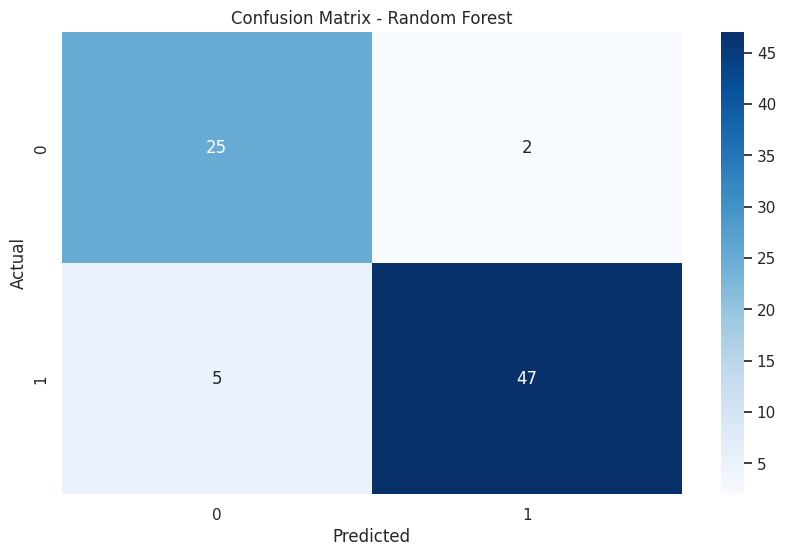

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [21]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



# Feature Importance

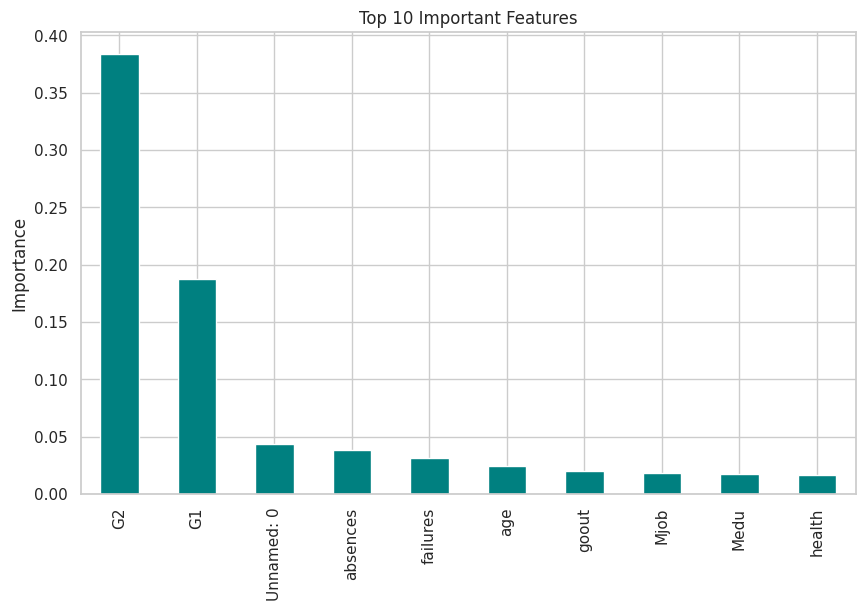

In [22]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar", color="teal")

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

# Compare with Portuguese Dataset

In [23]:
df2 = pd.read_csv("por2.csv")
print("Portuguese Dataset Shape:", df2.shape)
df2.head()

Portuguese Dataset Shape: (649, 34)


,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,GP,F,18,U,GT3,A,4,4,at_home,...,4,3,4,1,1,3,4,0,11,11
1,1,GP,F,17,U,GT3,T,1,1,at_home,...,5,3,3,1,1,3,2,9,11,11
2,2,GP,F,15,U,LE3,T,1,1,at_home,...,4,3,2,2,3,3,6,12,13,12
3,3,GP,F,15,U,GT3,T,4,2,health,...,3,2,2,1,1,5,0,14,14,14
4,4,GP,F,16,U,GT3,T,3,3,other,...,4,3,2,1,2,5,0,11,13,13
